## Interpolazione di funzioni

Si parla di interpolazione di funzioni quando i punti da interpolare appartengono al grafico di un'altra funzione, la cui espressione analitica può essere nota oppure no.

In altri termini, si assume che le ordinate dei punti $(x_i,y_i)$, siano le immagini dei nodi tramite una funzione $f$, ossia
$$y_i =f(x_i), \ \ i=0,...,n $$

In questo caso, se $p(x)$ è una funzione interpolante i dati $(x_i,y_i)$, si dice anche che interpola la funzione $f$.

**Esempio** di interpolazione di una funzione nota,
$$ \frac{\sin(6x)(3x)^2}{3x+4}$$
rispetto ai nodi $[0,1,1.5,2]$

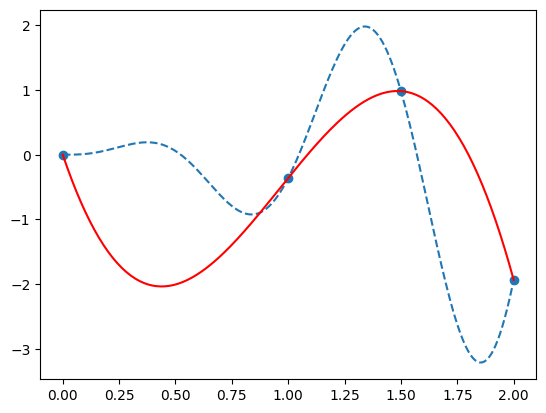

In [31]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: np.sin(6*x)*(3*x)**2/(3*x+4)
xx = np.linspace(0,2,num=200)
yy = f(xx)
plt.plot(xx,yy,'--')
x = np.array([0,1,1.5,2])
y = f(x)
plt.scatter(x,y)

b = np.polyfit(x,y,x.size-1)
zz = np.polyval(b,xx)

plt.plot(xx,zz,'-r')

plt.show()

**Significato del risultato**

Possiamo ipotizzare che la funzione tratteggiata in azzurro sia l'osservazione nel tempo di un determinato fenomeno fisico. Ma è impossibile effettuare un numero infinito di rilevazioni; per questo abbiamo un insieme di punti scollegati tra loro.

La linea rossa corrisponde all'interpolazione polinomiale dei punti rilevati. Costituisce una **nuova funzione apporossimazione della funzione nonlineare originale** (linea azzurra tratteggiata).

**Il polinomio di interpolazione di una funzione può essere considerato una approssimazione della funzione stessa?**

* Sebbene si possa formalizzare il concetto di "approssimazione
di una funzione", cerchiamo di rispondere alla domanda ragionando sulla somiglianza tra il grafico di $f$ e quello del suo polinomio di interpolazione.

* Nell'esempio precedente, i due grafici non sono particolarmente simili. Per renderli più vicini, una strategia ragionevole potrebbe essere quella di utilizzare un maggior numero di nodi nell'intervallo.

Sperimentiamo la correttezza di questa supposizione, scegliendo $n$ nodi equispaziati nell'intervallo di riferimento. Proviamo i valori $n=4$ e $n=15$.

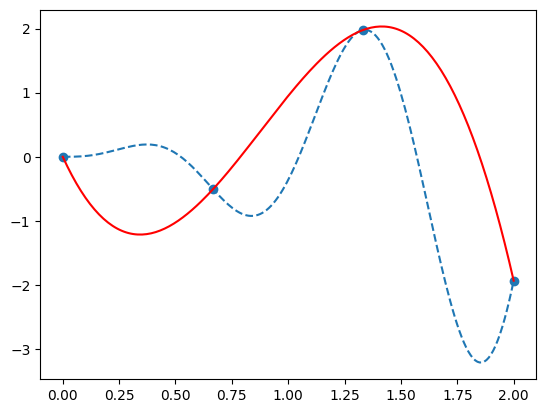

In [32]:
# Aumentando il numero di punti campione della funzione nonlineare originale ottengo un'approssimazione migliore;
# Inoltre dato che i punti sono equispaziati, mantenendo lo stesso intervallo ottengo punti più ravvicinati, e quindi un'approssimazione migliore.

n = 4   # to 15
x = np.linspace(0,2,num=n)
y = f(x)
b = np.polyfit(x,y,x.size-1)
zz = np.polyval(b,xx)
plt.plot(xx,yy,'--')
plt.scatter(x,y)
plt.plot(xx,zz,'-r')

plt.show()

Nell'esempio precedente la strategia di scegliere un numero maggiore di nodi sempre più vicini tra loro sembra dare buoni risultati, poiché i grafici del polinomio di interpolazione su 15 nodi e quello della funzione stessa sono sostanzialmente sovrapposti.

**Questa conclusione è vera in generale per qualsiasi funzione?**

Ripetiamo l'esperimento sulla funzione seguente
$$f(x) = \frac{1}{1+25x^2} $$
(detta funzione di Runge), utilizzando **nodi equispaziati** in numero crescente
nell'intervallo $[-1,1]$.

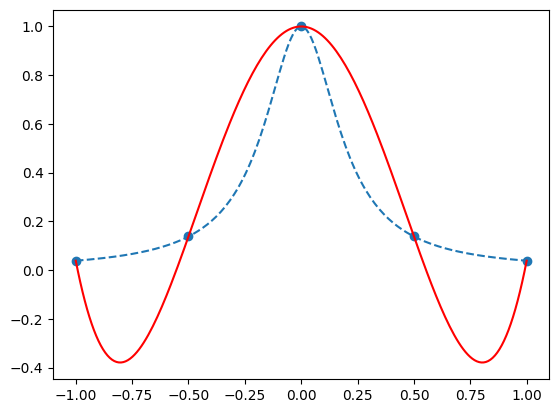

In [39]:
f = lambda x: 1/(1.+25*x**2)
n = 5   # to 15
x = np.linspace(-1,1,num=n)
y = f(x)
plt.scatter(x,y)
b = np.polyfit(x,y,x.size-1)

xx = np.linspace(-1,1,num=200)
yy = f(xx)
zz = np.polyval(b,xx)
plt.plot(xx,yy,'--')
plt.plot(xx,zz,'-r')
plt.show()


L'effetto che osserviamo viene riferito come **fenomeno di Runge**: scegliendo nodi equispaziati, all'aumentare del loro numero e, di conseguenza del grado del polinomio interpolante, l'approssimazione peggiora in prossimità degli estremi dell'intervallo, mentre si ha una buona sovrapposizione nella parte centrale.

**Come si può evitare questo deterioramento dell'approssimazione ottenuta col polinomio?**

L'intuizione è di scegliere i nodi non in modo uniforme nell'intervallo, ma in modo che siano più fitti in prossimità degli estremi, dove c'è bisogno di maggior controllo.

Questo è il criterio dei **nodi di Chebychev**



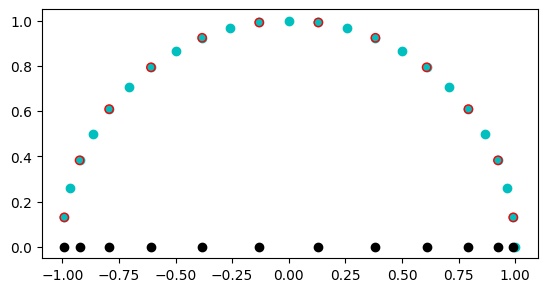

In [37]:
#Costruzione dei nodi di Chebychev


fig,ax = plt.subplots()
ax.set_aspect("equal")

#1. Definiamo il numero di nodi da creare
n = 11

#3. Partizioniamo gli angoli tra [0,pi] in 2(n+1) parti uguali
theta = np.pi/2/(n+1)*np.arange(2*(n+1))

#4. Plottiamo i punti corrispondenti sulla circonferenza goniometrica
ax.scatter(np.cos(theta),np.sin(theta),c='c')

#5. Selezioniamo solo i punti con indice dispari
beta = theta[1::2]
ax.scatter(np.cos(beta),np.sin(beta),edgecolor='r',facecolor='None')

#6. Otteniamo finalmente i nodi di Chebychev come le ascisse dei punti selezionati
ax.scatter(np.cos(beta),np.zeros(beta.size),c='k')


plt.show()



In sintesi, la formula dei nodi di Chebychev nell'intervallo $[-1,1]$ è la seguente
$$x_i = \cos\left(\frac{(2i+1)\pi}{2(n+1)} \right),\ \ i=0,...,n $$

Ripetiamo l'esperimento con la funzione di Runge e nodi di Chebychev.

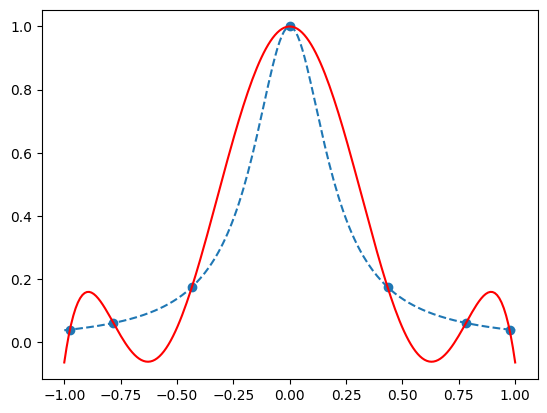

In [38]:
f = lambda x: 1/(1.+25*x**2)
n = 6
x = np.cos((2*np.arange(n+1)+1)*np.pi/2/(n+1)) #nodi di Chebychev
y = f(x)
plt.scatter(x,y)
b = np.polyfit(x,y,x.size-1) #coefficienti del polinomio

#Creazione dei grafici
xx = np.linspace(-1,1,num=200)
yy = f(xx)
zz = np.polyval(b,xx)
plt.plot(xx,yy,'--')
plt.plot(xx,zz,'-r')
plt.show()

In questo caso, aumentando il numero dei nodi, l'accuratezza dell'approssimazione migliora.

Si può dimostrare che la scelta dei nodi di Chebychev è **ottimale** nel senso che, tra tutte le infinite scelte possibili per i nodi di interpolazione, è quella che rende migliore l'approssimazione del polinomio rispetto alla funzione interpolata.